In [1]:
# Initialization
#%matplotlib inline
%matplotlib widget

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

import numpy
import h5py
import hdf5plugin
from h5glance import H5Glance

In [2]:
# Plot helper

from typing import NamedTuple

class Result(NamedTuple):
    """Store benchmark result"""

    raw_nbytes: int
    compressed_nbytes: int
    write_duration: float
    read_duration: float
    chunks: tuple[int]

    compression_rate = property(
        lambda self: self.raw_nbytes / self.compressed_nbytes)
    write_speed = property(
        lambda self: (self.raw_nbytes / 1024**2) / self.write_duration,
        doc="Unit: MB/sec")
    read_speed = property(
        lambda self: (self.raw_nbytes / 1024**2) / self.read_duration,
        doc="Unit: MB/sec")


def display_results(title: str='', key=None, **results):
    """Plot comparison of compression results.

    :param title: Additional dataset name
    :param key: Key function to customize the sort
    :param **results: {compression-name: Result} mapping
    """
    # Sort results by compression rate
    results = dict(sorted(
        results.items(),
        key=(lambda item: item[1].compression_rate) if key is None else key,
    ))

    names = list(results.keys())
    write_speed = numpy.array([r.write_speed for r in results.values()])
    read_speed = numpy.array([r.read_speed for r in results.values()])
    c_rate = numpy.array([r.compression_rate for r in results.values()])

    #print(f"hdf5plugin_config: {results[names[0]].config}")

    fig, axes = plt.subplots(1, 2)
    speed_plt, c_rate_plt = axes

    fig.suptitle(title)

    ticks = numpy.arange(len(names))

    # Speed
    speed_plt.barh(y=ticks, width=write_speed, height=0.4, align='edge', label="Write")
    speed_plt.barh(y=ticks-.4, width=read_speed, height=0.4, align='edge', label="Read")
    speed_plt.set_xlabel("Speed [MB/s]")
    speed_plt.autoscale(axis='y')
    speed_plt.yaxis.set_ticks(ticks)
    speed_plt.yaxis.set_ticklabels(names, fontsize=8)
    speed_plt.set_ylim(-0.5, len(ticks)-0.5)
    speed_plt.grid(axis="x")
    speed_plt.legend()

    # Compression ratio
    c_rate_plt.barh(y=ticks, width=c_rate)
    c_rate_plt.set_xlabel("Compression rate")
    c_rate_plt.autoscale(axis='y')
    c_rate_plt.yaxis.set_ticks(ticks)
    c_rate_plt.yaxis.set_ticklabels([''] * len(ticks))
    c_rate_plt.set_ylim(-0.5,len(ticks)-0.5)
    c_rate_plt.axvline(1, color="red")
    c_rate_plt.grid(axis="x")

    fig.tight_layout()

    # Tooltip
    tooltip = c_rate_plt.annotate(
        "", (0, 0), backgroundcolor="lightyellow",
        verticalalignment="top", xycoords='figure pixels')
    tooltip.set_visible(False)

    def hover(event):
        if event.inaxes in (speed_plt, c_rate_plt):
            index = numpy.clip(round(event.ydata), 0, len(names)-1)
            tooltip.set_text(
                f"{names[index]}\n"
                f"Comp. Rate: {c_rate[index]:.2f}x\n"
                f"Write: {write_speed[index]:.1f}MB/s\n"
                f"Read: {read_speed[index]:.1f}MB/s")
            tooltip.set_x(event.x + 15)
            tooltip.set_y(event.y)
            tooltip.set_visible(True)
        else:
            tooltip.set_visible(False)
        fig.canvas.draw_idle()

    def resize(event):
        fig.tight_layout()

    fig.canvas.mpl_connect("motion_notify_event", hover)
    fig.canvas.mpl_connect("resize_event", resize)

In [3]:
import os
import sys

print('Python:', sys.version)

config = hdf5plugin.get_config()
print(f"""hdf5plugin:
* Version: {hdf5plugin.version}
* Build config:
{'''
'''.join(f'  - {k}: {v}' for k, v in config.build_config._asdict().items())}
""")

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
hdf5plugin:
* Version: 6.0.0
* Build config:
  - openmp: False
  - native: False
  - bmi2: False
  - sse2: True
  - ssse3: False
  - avx2: False
  - avx512: False
  - cpp11: True
  - cpp14: True
  - cpp20: True
  - ipp: False
  - filter_file_extension: .dll
  - embedded_filters: ('blosc', 'blosc2', 'bshuf', 'bzip2', 'fcidecomp', 'lz4', 'sperr', 'sz', 'sz3', 'zfp', 'zstd')



In [4]:
import json

benchmarks = json.load(open("benchmark-4-cpu.json"))
config = benchmarks["config"]
results = {k: Result(**v) for k, v in benchmarks["results"].items()}

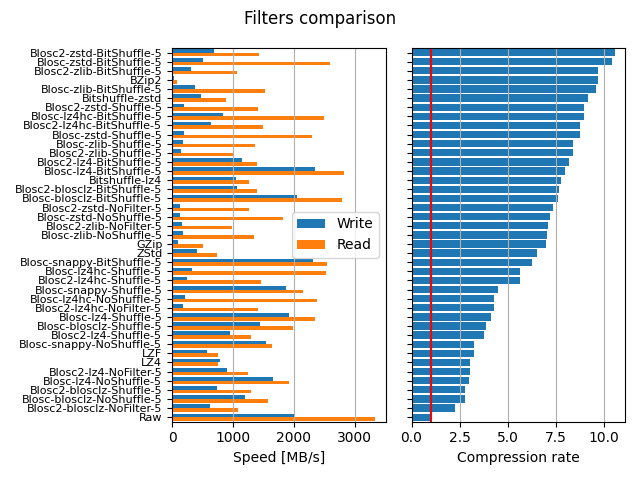

In [5]:
display_results(
    title="Filters comparison",
    **results
)